# Physical/ergonomic exposures and work-related musculoskeletal pain
### A nationwide analysis of Korean workers for targeted physical therapy (7th KWCS, 2023)

6 cells · Colab *Runtime ▸ Run all*. English figures. Outputs → `output/run_<timestamp>/`.
**Primary outcome = work-related** site-specific MSD. Interpretable ML (SHAP) included. Distinct from prior work (physical exposures, not psychosocial autonomy/emotional labor).

In [18]:
# ===== Cell 1 — Setup =====
import sys, os, warnings; warnings.filterwarnings('ignore')
IN_COLAB='google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive')
    get_ipython().system('pip -q install shap lightgbm')
    _root='/content/drive/MyDrive/완석_구글자료/연구자료/20260313_kosha/안정재_IAPTR 논문'
    BASE=next((c for c in [os.path.join(_root,'IAPTR_paper'), _root] if os.path.exists(os.path.join(c,'input'))), _root)
else:
    BASE=os.getcwd()
import numpy as np, pandas as pd
import statsmodels.api as sm, statsmodels.formula.api as smf
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from datetime import datetime
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight','pdf.fonttype':42,'ps.fonttype':42,
 'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],'font.size':10,
 'axes.titlesize':11,'axes.titleweight':'bold','axes.labelsize':10,'axes.spines.top':False,'axes.spines.right':False,
 'axes.linewidth':0.8,'xtick.labelsize':9,'ytick.labelsize':9,'legend.fontsize':8.5,'legend.frameon':False,
 'figure.constrained_layout.use':True})
CB=['#0072B2','#D55E00','#009E73','#CC79A7','#E69F00','#56B4E9','#F0E442','#000000']
INPUT,OUTPUT=os.path.join(BASE,'input'),os.path.join(BASE,'output')
DATA=os.path.join(INPUT,'kwcs7_msd_subset.csv')  # 작은 부분집합(빠른 동기화)
if not os.path.exists(DATA): DATA=os.path.join(INPUT,'(데이터) 2023년 제7차 근로환경조사.csv')  # 폴백: 원본
W_DESC,W_REG,MISS='wt2','wt3',[8,9]
RUN_DIR=os.path.join(OUTPUT, datetime.now().strftime('run_%Y%m%d_%H%M%S'))
def out_dir(n): d=os.path.join(RUN_DIR,n); os.makedirs(d,exist_ok=True); return d
def save(fig,folder,name):
    d=out_dir(folder); b=os.path.splitext(name)[0]; fig.savefig(os.path.join(d,b+'.png'),dpi=300); fig.savefig(os.path.join(d,b+'.pdf'))
    print('saved:',os.path.relpath(os.path.join(d,b+'.png'),OUTPUT)); plt.show()
SITES={'msd_back_wr':'Work-related low-back pain','msd_upper_wr':'Work-related upper-limb pain','msd_lower_wr':'Work-related lower-limb pain'}
EXPO={'erg_posture':'Painful/tiring postures','erg_lift_person':'Lifting/moving people','erg_heavy':'Carrying/moving heavy loads',
      'erg_stand':'Prolonged standing','erg_sit':'Prolonged sitting','erg_repeat':'Repetitive hand/arm movements','vibration':'Vibration'}
def stars(p): return '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
print('env:', 'Colab' if IN_COLAB else 'local','| data:',os.path.exists(DATA))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
env: Colab | data: True


In [19]:
# ===== Cell 2 — Load, recode (PRIMARY = work-related MSD), sample =====
def num(x): return pd.to_numeric(x,errors='coerce')
def na(x,c=MISS): v=num(x); return v.mask(v.isin(c))
df=pd.read_csv(DATA,encoding='utf-8-sig',low_memory=False).replace('#NULL!',np.nan)
d=pd.DataFrame(index=df.index)
# Work-related site-specific MSD: symptom present & work-related=1 ->1; symptom absent ->0; missing ->NaN
for k,src in [('back','heal_prob1'),('upper','heal_prob2'),('lower','heal_prob3')]:
    hb=na(df[src]); wr=num(df[src+'_1'])
    d[f'msd_{k}_wr']=np.where(hb==1,(wr==1).astype(float),np.where(hb==2,0.0,np.nan))
# Exposures (frequent = at least half of working time, code<=4)
EXMAP={'erg_posture':'hazard_erg1','erg_lift_person':'hazard_erg2','erg_heavy':'hazard_erg3','erg_stand':'hazard_erg4',
       'erg_sit':'hazard_erg5','erg_repeat':'hazard_erg6','vibration':'hazard_phy1'}
for k,v in EXMAP.items(): d[k]=(na(df[v])<=4).astype(float)
# Covariates
d['female']=(na(df['gender'],[])==2).astype(float)
et,es=na(df['emp_type'],[]),num(df['emp_stat']); emp=pd.Series(np.nan,index=df.index,dtype='object')
emp[(et==3)&(es==1)]='1_wage_perm'; emp[(et==3)&(es.isin([2,3]))]='2_wage_precarious'; emp[et.isin([1,2,4])]='3_selfemp_etc'
d['emp3']=pd.Categorical(emp,categories=['1_wage_perm','2_wage_precarious','3_selfemp_etc'])
d['age']=na(df['age'],[]); d['agegrp']=pd.cut(d['age'],[14,29,39,49,59,200],labels=['15-29','30-39','40-49','50-59','60+'])
occmap={1:'WhiteCollar',2:'WhiteCollar',3:'WhiteCollar',4:'ServiceSales',5:'ServiceSales',6:'Manual',7:'Manual',8:'Manual',9:'Manual'}
d['occ_g']=na(df['occ'],[]).map(occmap)
d['shift']=(na(df['wtime_length5'])==1).astype(float); wh=na(df['wtime_week'],[]); d['whours']=wh.fillna(wh.median())
d[W_DESC]=num(df[W_DESC]); d[W_REG]=num(df[W_REG])
need=list(SITES)+['female','agegrp','emp3','occ_g','whours']+list(EXPO)
s=d.dropna(subset=need).copy(); s=s[(s.age>=15)&(s.age<=69)].copy()
print(f'Analytic sample N={len(s):,} / total {len(d):,}')
print('Work-related MSD prevalence:', {SITES[k]:round(s[k].mean()*100,1) for k in SITES})
s.to_csv(f"{out_dir('00_analytic_data')}/analytic_sample.csv",index=False,encoding='utf-8-sig')

Analytic sample N=44,347 / total 50,195
Work-related MSD prevalence: {'Work-related low-back pain': np.float64(22.2), 'Work-related upper-limb pain': np.float64(27.1), 'Work-related lower-limb pain': np.float64(13.6)}


In [20]:
# ===== Cell 3 — Models & tables (single-exposure aOR + PAF; multivariable) =====
from IPython.display import display
COV="C(agegrp)+female+C(emp3)+C(occ_g)+whours+shift"
def wmean(col,mask=None):
    g=s if mask is None else s[mask]; m=g[col].notna(); return np.average(g.loc[m,col],weights=g.loc[m,W_DESC]) if m.sum() else np.nan
def fitg(f,data=None):
    data=s if data is None else data; mdl=smf.glm(f,data=data,family=sm.families.Binomial(),freq_weights=data[W_REG])
    for ct in ['HC1','HC0','nonrobust']:
        try: return mdl.fit(cov_type=ct)
        except Exception: continue
    return mdl.fit()
def aor1(y,x):
    m=fitg(f"{y} ~ {x}+{COV}"); ci=m.conf_int().loc[x]; return np.exp(m.params[x]),np.exp(ci[0]),np.exp(ci[1]),m.pvalues[x]
rows=[]
for k,lab in {**SITES,**{x:'[exposure] '+EXPO[x] for x in EXPO}}.items():
    rows.append({'Indicator':lab,'Overall%':round(wmean(k)*100,1),'Men%':round(wmean(k,s.female==0)*100,1),'Women%':round(wmean(k,s.female==1)*100,1),
                 'Office%':round(wmean(k,s.occ_g=='WhiteCollar')*100,1),'Service/Sales%':round(wmean(k,s.occ_g=='ServiceSales')*100,1),'Manual%':round(wmean(k,s.occ_g=='Manual')*100,1)})
t1=pd.DataFrame(rows); t1.to_csv(f"{out_dir('01_descriptive')}/table1_prevalence.csv",index=False,encoding='utf-8-sig')
rows=[]; aORmat={}; pmat={}
for y,yl in SITES.items():
    for x,xl in EXPO.items():
        a,lo,hi,p=aor1(y,x); pe=wmean(x); paf=pe*(a-1)/(pe*(a-1)+1)*100 if a>1 else 0.0
        rows.append({'Outcome':yl,'Exposure':xl,'aOR (95% CI)':f"{a:.2f} ({lo:.2f}-{hi:.2f}){stars(p)}",'Exposed%':round(pe*100,1),'PAF%':round(paf,1)}); aORmat[(y,x)]=a; pmat[(y,x)]=p
t2=pd.DataFrame(rows); t2.to_csv(f"{out_dir('02_main_models')}/table2_single_exposure_aOR.csv",index=False,encoding='utf-8-sig')
rows=[]
for y,yl in SITES.items():
    m=fitg(f"{y} ~ "+"+".join(EXPO)+"+"+COV)
    for x,xl in EXPO.items():
        ci=m.conf_int().loc[x]; rows.append({'Outcome':yl,'Exposure':xl,'Independent aOR (95% CI)':f"{np.exp(m.params[x]):.2f} ({np.exp(ci[0]):.2f}-{np.exp(ci[1]):.2f}){stars(m.pvalues[x])}"})
t3=pd.DataFrame(rows); t3.to_csv(f"{out_dir('02_main_models')}/table3_multivariable.csv",index=False,encoding='utf-8-sig')
print('TABLE 1'); display(t1); print('TABLE 2'); display(t2); print('TABLE 3'); display(t3)
globals().update(dict(t1=t1,t2=t2,t3=t3,aORmat=aORmat,pmat=pmat))

TABLE 1


,Indicator,Overall%,Men%,Women%,Office%,Service/Sales%,Manual%
0,Work-related low-back pain,19.7,20.0,19.2,9.6,19.4,33.1
1,Work-related upper-limb pain,24.4,23.5,25.6,14.7,25.5,36.6
2,Work-related lower-limb pain,11.2,10.7,11.8,5.4,11.3,18.7
3,[exposure] Painful/tiring postures,25.3,27.0,23.1,13.8,25.2,40.5
4,[exposure] Lifting/moving people,6.4,6.2,6.6,5.4,7.2,7.2
5,[exposure] Carrying/moving heavy loads,15.5,20.2,9.3,6.1,13.9,28.8
6,[exposure] Prolonged standing,55.5,54.0,57.3,35.3,75.0,69.0
7,[exposure] Prolonged sitting,58.8,60.3,57.0,77.6,41.1,45.9
8,[exposure] Repetitive hand/arm movements,40.1,40.2,39.9,30.6,40.1,52.5
9,[exposure] Vibration,14.9,21.0,7.0,6.8,6.4,31.2


TABLE 2


,Outcome,Exposure,aOR (95% CI),Exposed%,PAF%
0,Work-related low-back pain,Painful/tiring postures,2.90 (2.76-3.06)***,25.3,32.5
1,Work-related low-back pain,Lifting/moving people,1.27 (1.15-1.40)***,6.4,1.7
2,Work-related low-back pain,Carrying/moving heavy loads,1.87 (1.76-1.98)***,15.5,11.8
3,Work-related low-back pain,Prolonged standing,1.41 (1.34-1.49)***,55.5,18.6
4,Work-related low-back pain,Prolonged sitting,0.85 (0.81-0.89)***,58.8,0.0
5,Work-related low-back pain,Repetitive hand/arm movements,1.87 (1.78-1.96)***,40.1,25.8
6,Work-related low-back pain,Vibration,1.52 (1.43-1.62)***,14.9,7.2
7,Work-related upper-limb pain,Painful/tiring postures,2.93 (2.79-3.08)***,25.3,32.9
8,Work-related upper-limb pain,Lifting/moving people,1.25 (1.14-1.36)***,6.4,1.5
9,Work-related upper-limb pain,Carrying/moving heavy loads,1.79 (1.69-1.89)***,15.5,10.8


TABLE 3


,Outcome,Exposure,Independent aOR (95% CI)
0,Work-related low-back pain,Painful/tiring postures,2.51 (2.36-2.67)***
1,Work-related low-back pain,Lifting/moving people,0.76 (0.69-0.85)***
2,Work-related low-back pain,Carrying/moving heavy loads,1.21 (1.13-1.30)***
3,Work-related low-back pain,Prolonged standing,1.14 (1.08-1.22)***
4,Work-related low-back pain,Prolonged sitting,0.93 (0.88-0.99)*
5,Work-related low-back pain,Repetitive hand/arm movements,1.17 (1.10-1.24)***
6,Work-related low-back pain,Vibration,1.12 (1.05-1.20)**
7,Work-related upper-limb pain,Painful/tiring postures,2.19 (2.06-2.32)***
8,Work-related upper-limb pain,Lifting/moving people,0.75 (0.68-0.83)***
9,Work-related upper-limb pain,Carrying/moving heavy loads,1.10 (1.02-1.17)**


saved: run_20260530_031856/02_main_models/fig1_heatmap.png


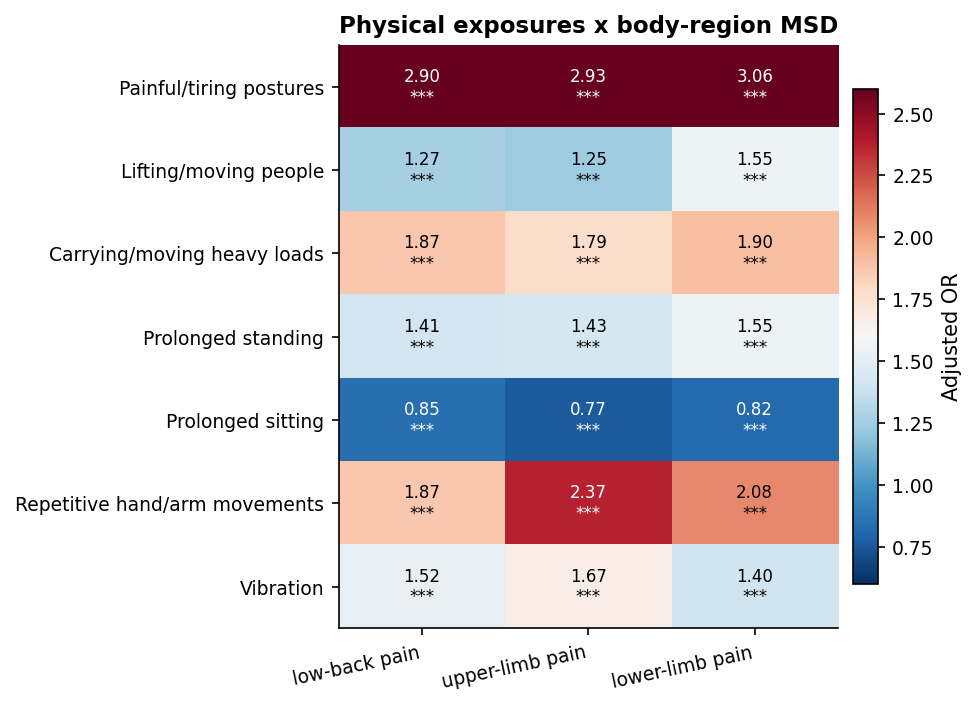

saved: run_20260530_031856/02_main_models/fig2_forest.png


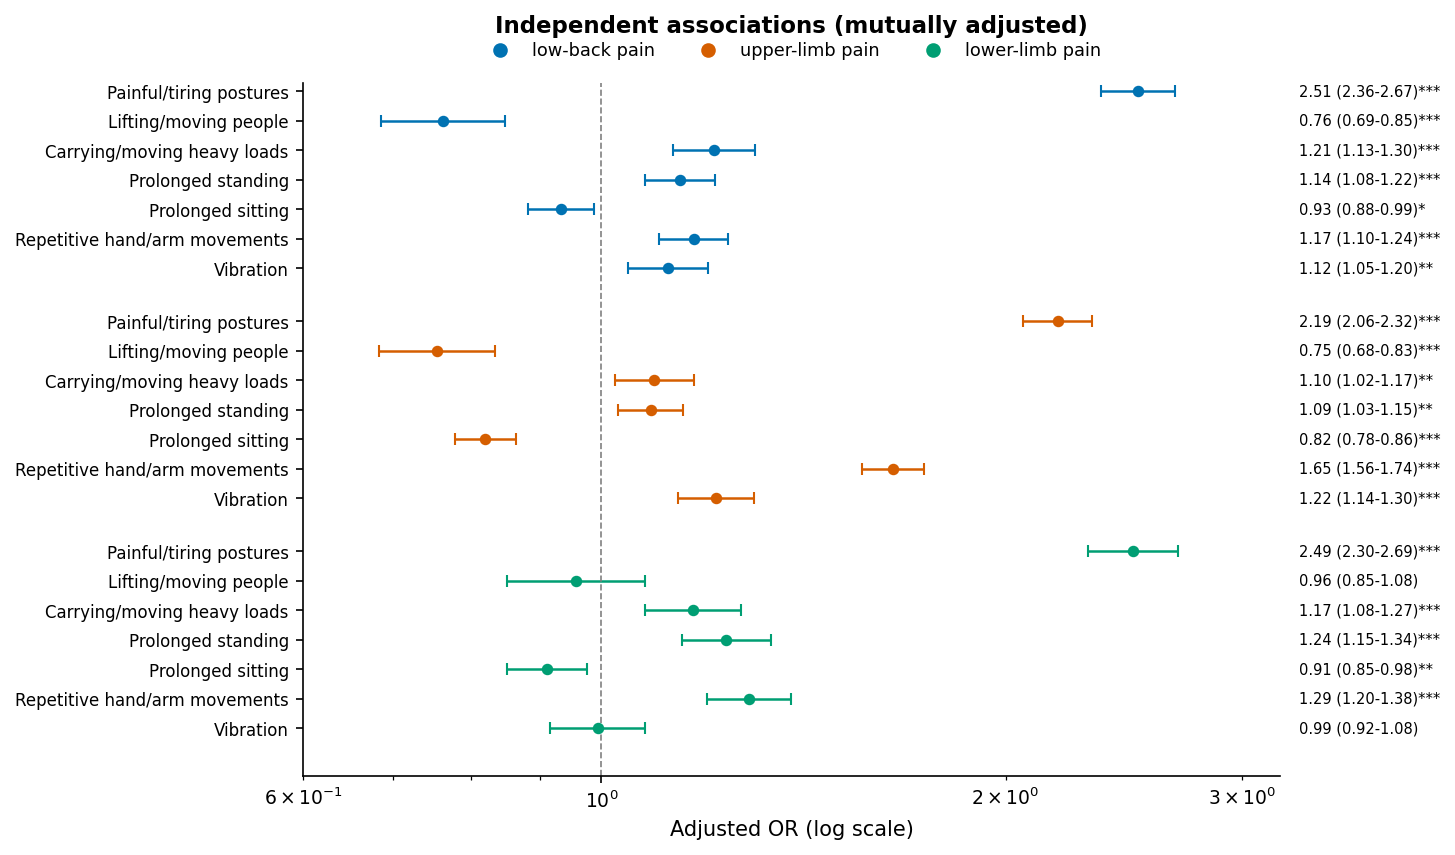

saved: run_20260530_031856/01_descriptive/fig3_by_occupation.png


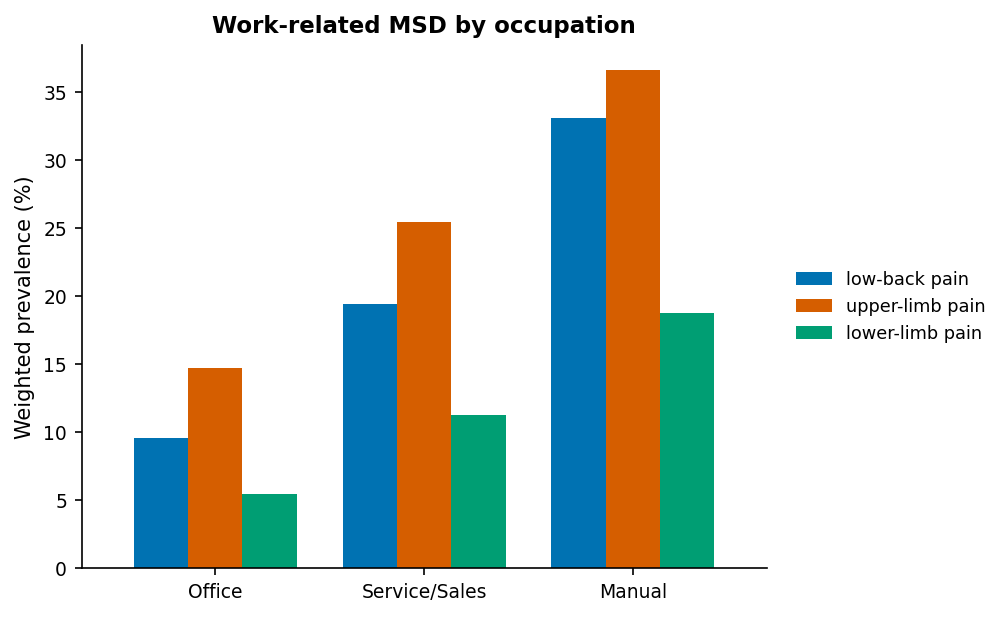

saved: run_20260530_031856/02_main_models/fig4_PAF.png


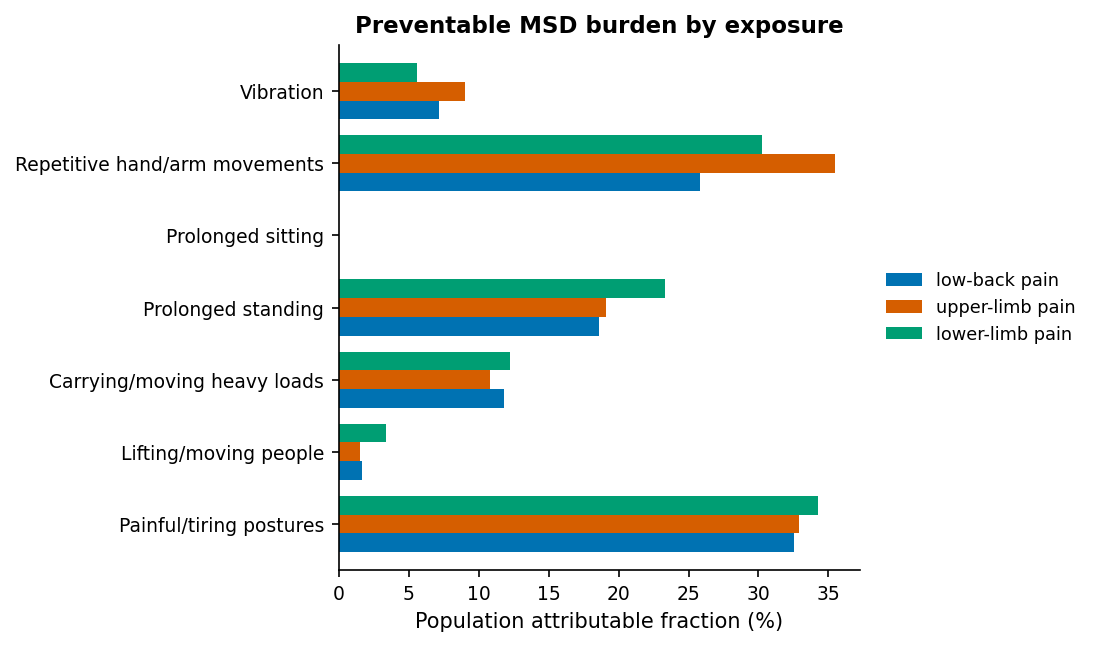

Figure 1. Adjusted odds ratios for physical/ergonomic exposures and work-related site-specific musculoskeletal pain.
Figure 2. Mutually adjusted odds ratios for physical exposures by MSD site.
Figure 3. Survey-weighted prevalence of work-related MSD by occupational group.
Figure 4. Population attributable fractions indicating preventable work-related MSD burden.


In [21]:
# ===== Cell 4 — Figures (heatmap, forest, prevalence, PAF) =====
caps=[]; cap=lambda n,t: caps.append(f"Figure {n}. {t}")
SK=list(SITES); XK=list(EXPO)
M=np.array([[aORmat[(y,x)] for y in SK] for x in XK]); P=np.array([[pmat[(y,x)] for y in SK] for x in XK])
fig,ax=plt.subplots(figsize=(6.4,4.6)); im=ax.imshow(M,cmap='RdBu_r',vmin=0.6,vmax=2.6,aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels([SITES[k].replace('Work-related ','') for k in SK],rotation=12,ha='right')
ax.set_yticks(range(len(XK))); ax.set_yticklabels([EXPO[k] for k in XK])
for i in range(len(XK)):
    for j in range(3): ax.text(j,i,f"{M[i,j]:.2f}\n{stars(P[i,j])}",ha='center',va='center',fontsize=8,color=('white' if (lambda _c:0.299*_c[0]+0.587*_c[1]+0.114*_c[2]<0.5)(im.cmap(im.norm(M[i,j]))) else 'black'))
cb=fig.colorbar(im,ax=ax,shrink=.85,pad=.03); cb.set_label('Adjusted OR'); ax.set_title('Physical exposures x body-region MSD')
save(fig,'02_main_models','fig1_heatmap.png'); cap(1,"Adjusted odds ratios for physical/ergonomic exposures and work-related site-specific musculoskeletal pain.")
# forest (multivariable)
fig,ax=plt.subplots(figsize=(8.4,6.0)); fig.set_layout_engine('none'); fig.subplots_adjust(left=0.34,right=0.66,top=0.9,bottom=0.08)
colm={SK[0]:CB[0],SK[1]:CB[1],SK[2]:CB[2]}; yy=0.0; ypos=[]; ylab=[]; pr=[]
for y in SK:
    m=fitg(f"{y} ~ "+"+".join(EXPO)+"+"+COV)
    for x in XK:
        ci=m.conf_int().loc[x]; pr.append((yy,np.exp(m.params[x]),np.exp(ci[0]),np.exp(ci[1]),colm[y],m.pvalues[x])); ypos.append(yy); ylab.append(EXPO[x]); yy+=1
    yy+=0.8
ymax=yy
for y0,a,lo,hi,c,p in pr:
    yv=ymax-y0; ax.errorbar(a,yv,xerr=[[a-lo],[hi-a]],fmt='o',color=c,capsize=3,lw=1.2,ms=4.5)
    ax.text(1.02,yv,f"{a:.2f} ({lo:.2f}-{hi:.2f}){stars(p)}",transform=ax.get_yaxis_transform(),va='center',ha='left',fontsize=7)
ax.set_yticks([ymax-p for p in ypos]); ax.set_yticklabels(ylab,fontsize=8); ax.axvline(1,ls='--',lw=.8,color='0.5'); ax.set_xscale('log'); ax.set_xlabel('Adjusted OR (log scale)'); ax.set_xlim(0.6,3.2); ax.set_ylim(0.2,ymax+0.3)
ax.legend(handles=[Line2D([0],[0],marker='o',ls='',color=colm[k],label=SITES[k].replace('Work-related ','')) for k in SK],loc='lower center',bbox_to_anchor=(0.5,1.01),ncol=3)
ax.set_title('Independent associations (mutually adjusted)',pad=24)
save(fig,'02_main_models','fig2_forest.png'); cap(2,"Mutually adjusted odds ratios for physical exposures by MSD site.")
# prevalence by occupation
fig,ax=plt.subplots(figsize=(6.6,4))
pd.DataFrame({SITES[k].replace('Work-related ',''):[wmean(k,s.occ_g==o)*100 for o in ['WhiteCollar','ServiceSales','Manual']] for k in SK},index=['Office','Service/Sales','Manual']).plot(kind='bar',ax=ax,color=CB[:3],width=.78)
ax.set_ylabel('Weighted prevalence (%)'); ax.set_title('Work-related MSD by occupation'); ax.legend(loc='center left',bbox_to_anchor=(1.02,.5)); plt.xticks(rotation=0)
save(fig,'01_descriptive','fig3_by_occupation.png'); cap(3,"Survey-weighted prevalence of work-related MSD by occupational group.")
# PAF
fig,ax=plt.subplots(figsize=(7.2,4.2))
pd.DataFrame({SITES[y].replace('Work-related ',''):[(lambda a,pe: pe*(a-1)/(pe*(a-1)+1)*100 if a>1 else 0)(aORmat[(y,x)],wmean(x)) for x in XK] for y in SK},index=[EXPO[k] for k in XK]).plot(kind='barh',ax=ax,color=CB[:3],width=.78)
ax.set_xlabel('Population attributable fraction (%)'); ax.set_title('Preventable MSD burden by exposure'); ax.legend(loc='center left',bbox_to_anchor=(1.02,.5))
save(fig,'02_main_models','fig4_PAF.png'); cap(4,"Population attributable fractions indicating preventable work-related MSD burden.")
open(f"{RUN_DIR}/figure_captions.txt",'w',encoding='utf-8').write("\n\n".join(caps)); print('\n'.join(caps))

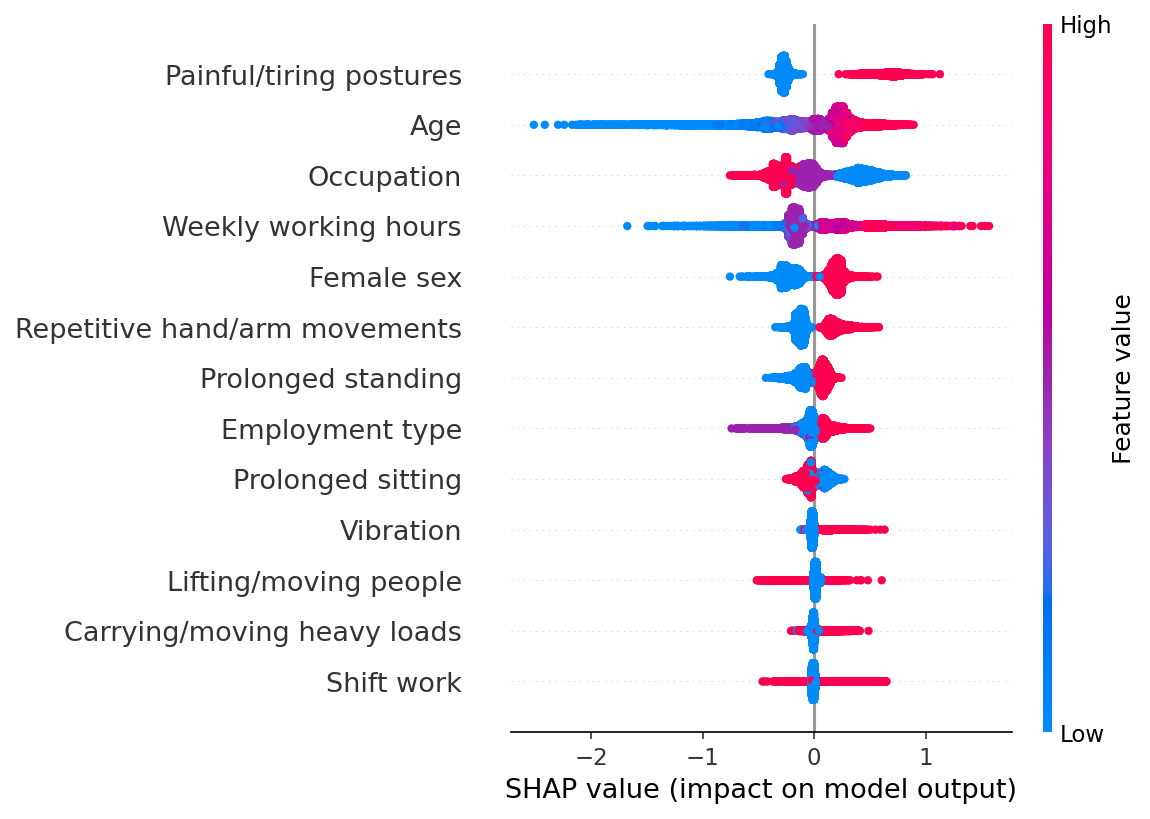

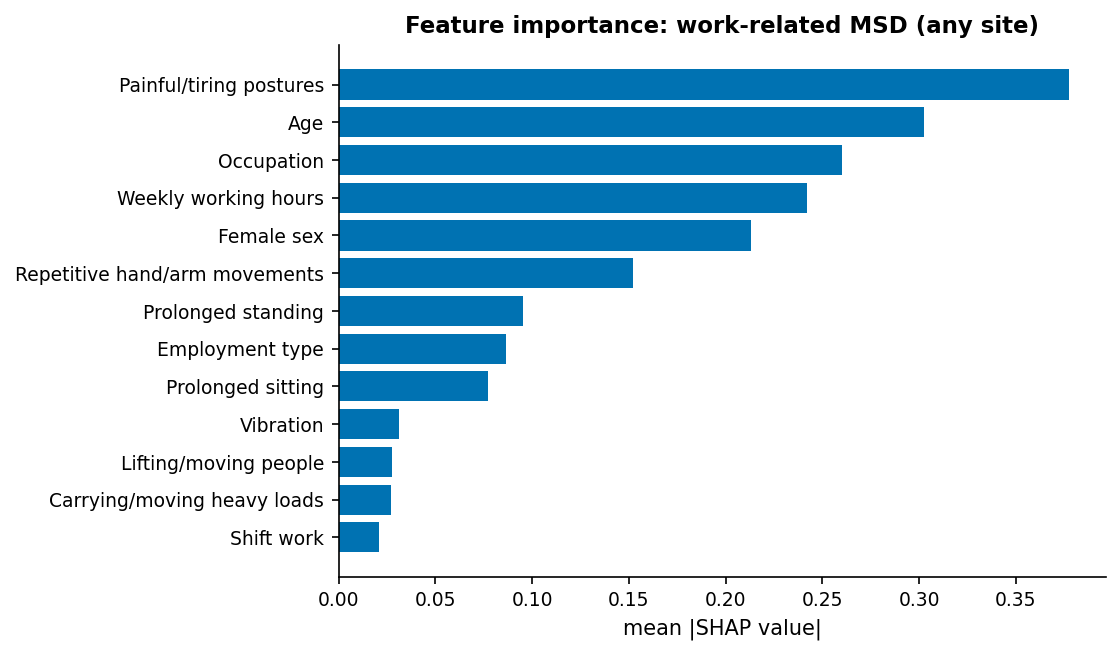

saved: fig5_shap_summary, fig6_shap_importance | top drivers: ['Painful/tiring postures', 'Age', 'Occupation', 'Weekly working hours', 'Female sex']


In [22]:
# ===== Cell 5 — Interpretable machine learning (SHAP): drivers of work-related MSD =====
import shap, matplotlib as mpl
from lightgbm import LGBMClassifier
mpl.rcParams['figure.constrained_layout.use']=False; plt.close('all')
s2=s.copy(); s2['any_wr']=((s2.msd_back_wr==1)|(s2.msd_upper_wr==1)|(s2.msd_lower_wr==1)).astype(int)
NICE={**EXPO,'age':'Age','female':'Female sex','whours':'Weekly working hours','shift':'Shift work','emp3':'Employment type','occ_g':'Occupation'}
feats=list(EXPO)+['age','female','whours','shift','emp3','occ_g']
X=s2[feats].copy()
for c in ['emp3','occ_g']: X[c]=X[c].astype('category').cat.codes
X=X.astype(float); y=s2['any_wr']
clf=LGBMClassifier(n_estimators=400,learning_rate=0.03,num_leaves=31,subsample=0.8,colsample_bytree=0.8,verbose=-1)
clf.fit(X,y,sample_weight=s2[W_REG],categorical_feature=['emp3','occ_g'])
Xp=X.rename(columns=NICE)
sv=shap.TreeExplainer(clf).shap_values(Xp); sv1=sv[1] if isinstance(sv,list) else sv
d5=out_dir('03_interpretable_ML')
plt.close('all'); shap.summary_plot(sv1,Xp,max_display=13,show=False)
fig=plt.gcf(); fig.set_size_inches(7.6,5.4)
fig.savefig(f"{d5}/fig5_shap_summary.png",dpi=300,bbox_inches='tight'); fig.savefig(f"{d5}/fig5_shap_summary.pdf",bbox_inches='tight'); plt.show(); plt.close('all')
imp=pd.DataFrame({'feature':Xp.columns,'mean_abs_shap':np.abs(sv1).mean(0)}).sort_values('mean_abs_shap')
imp.to_csv(f"{d5}/shap_importance.csv",index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(6.6,4.6)); ax.barh(imp.feature,imp.mean_abs_shap,color=CB[0]); ax.set_xlabel('mean |SHAP value|'); ax.set_title('Feature importance: work-related MSD (any site)')
fig.savefig(f"{d5}/fig6_shap_importance.png",dpi=300,bbox_inches='tight'); fig.savefig(f"{d5}/fig6_shap_importance.pdf",bbox_inches='tight'); plt.show(); plt.close('all')
print('saved: fig5_shap_summary, fig6_shap_importance | top drivers:', list(imp.feature)[::-1][:5])

## Outputs (per run)
`00_analytic_data` · `01_descriptive`(Fig3) · `02_main_models`(Tab2-3; Fig1,2,4) · `03_interpretable_ML`(SHAP Fig5-6) · `figure_captions.txt`.
Primary outcome = work-related MSD. SHAP showcases interpretable ML (student's strength). Distinct from existing papers.